# Lab Activity01 Solution

In [1]:
# Import needed libraries
import os
import pandas as pd
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.weightstats import ttest_ind as sm_ttest
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import TTestIndPower, NormalIndPower
import seaborn as sns
import matplotlib.pyplot as plt

## Activity 1: Comparing two proportions

### Question 1: Visualize the mass of penguins across different islands. What does this tell you

In [2]:
# First we will read in the penguins dataset
peng = pd.read_csv("../data/penguins.csv")

# Now, let's see if there is any missing data for body mass, since that is the variable of interest for this question
print(peng.isna().sum())
print()

# Since there are only two instances of missing body mass, we can drop those in our analysis
peng_mass = peng.dropna(subset=["body_mass_g"]).copy()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64



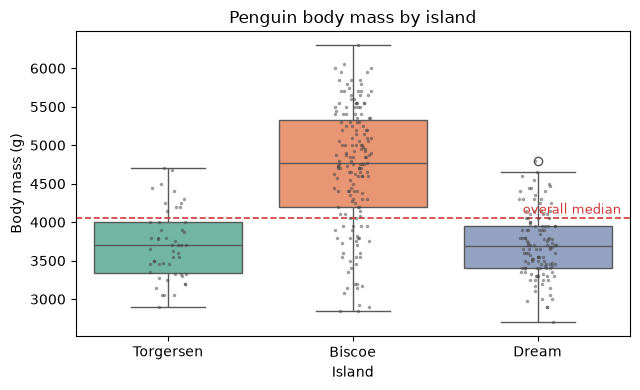

           count    mean  median    std
island                                 
Biscoe       167  4716.0  4775.0  782.9
Dream        124  3712.9  3687.5  416.6
Torgersen     51  3706.4  3700.0  445.1


In [3]:
plt.figure(figsize=(6.5, 4))
sns.boxplot(
    data=peng_mass,
    x="island",
    y="body_mass_g",
    hue="island",
    palette="Set2",
    legend=False,
)

# Overlay the individual penguins using stripplot and put a dotted line where the overall median is. 
sns.stripplot(
    data=peng_mass, x="island", y="body_mass_g",
    color="0.25", size=2.5, alpha=0.5,
)
plt.axhline(
    peng_mass["body_mass_g"].median(),
    color="#d03b3b", linestyle="--", linewidth=1.2,
)
plt.text(
    2.45, peng_mass["body_mass_g"].median() + 60,
    "overall median", color="#d03b3b", fontsize=9, ha="right",
)
plt.xlabel("Island")
plt.ylabel("Body mass (g)")
plt.title("Penguin body mass by island")
plt.tight_layout()
plt.show()

# The numbers behind the picture.
print(
    peng_mass.groupby("island")["body_mass_g"]
    .agg(["count", "mean", "median", "std"])
    .round(1)
)

Q1 continued: The plot above tells us that penguins on Biscoe island are larger than penguins on either Torgerson or Dream islands. 

### Question 2: Are the penguins on Biscoe Island larger

In [4]:
# Q2 Are penguins on Biscoe island larger?
# The plot above seems to indicate this, now lets do the proportion test to see
# First, let's define a new variable "is_large" to indicate whether penguins that live on Biscoe island ARE in fact larger. 

peng_mass["is_large"] = peng_mass["body_mass_g"] > peng_mass["body_mass_g"].median()

# We can also look at the median body mass across all penguins
print(peng_mass["body_mass_g"].median())


4050.0


In [5]:
# We can look at the first 10 rows of this data frame to see that
# 1. is_large was added to the dataframe
# 2. our calculation did what we were expecting. 

peng_mass.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,is_large
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,False
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,False
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,False
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,False
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,False
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007,False
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007,True
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007,False
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007,True
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007,False


In [6]:
# The crosstab function in pandas gives us a look at large penguins on Biscoe island vs Torgerson/Dream
# Note: You don't need this function to solve this problem, but it can be a useful way to look at the data
pd.crosstab(peng_mass["island"] == "Biscoe", peng_mass["is_large"])


is_large,False,True
island,,
False,140,35
True,36,131


In [7]:
# Calculate large penguins vs total penguins
on_biscoe = peng_mass["island"] == "Biscoe"

large_pengs = [
    peng_mass.loc[on_biscoe, "is_large"].sum(), # Large penguins on Biscoe
    peng_mass.loc[~on_biscoe, "is_large"].sum(), # Large penguins not on Biscoe
]
total_pengs = [
    on_biscoe.sum(), # Total Penguins on Biscoe
    (~on_biscoe).sum(), # Total Penguins not on Biscoe
]

# This gives us the arrays we need for the z-test (Note similarity with the cross-tab)
print(large_pengs)
print(total_pengs)
print("----")
print("Proportions: Large penguins on Biscoe: ", large_pengs[0]/total_pengs[0])
print("Proportions: Large penguins not on Biscoe: ", large_pengs[1]/total_pengs[1])

[np.int64(131), np.int64(35)]
[np.int64(167), np.int64(175)]
----
Proportions: Large penguins on Biscoe:  0.7844311377245509
Proportions: Large penguins not on Biscoe:  0.2


In [8]:
# The z-test takes as arguments "successes" (which in this case is the number of large penguins)
# and nobs = total number of observations (in this case, total number of penguins on Biscoe/not-Biscoe)
z_stat, p_value = proportions_ztest(large_pengs, total_pengs)
print(z_stat, p_value)

10.809691047645456 3.0971137203180796e-27


Q2 continued: According to our z-test above, Penguins on Biscoe island are larger by an astonishing amount, with a p-value on the order of 10^-27!!! 

Note: We used the default 'two-sided' test in the example above, which is the default argument for the proportions_ztest function. A one-sided t-test ('smaller' or 'larger') assumes the direction of the difference BEFORE seeing the data. In this case, it ends up not mattering if we choose "larger", because the p-value is so small, but we have to be careful in cases where the p-value is closer to 0.05, since the value we get is defined relative to the argument order, which in this case is arbitrary. 

More importantly, whenever a p-value is this small, you should immediately be suspicious. It makes sense to dig in further to understand what is going on. We'll do this next. 

### Question 3: Visualize which species of penguins live on each island. How does that change your answer to the question: Are the penguins on Biscoe Island larger? 

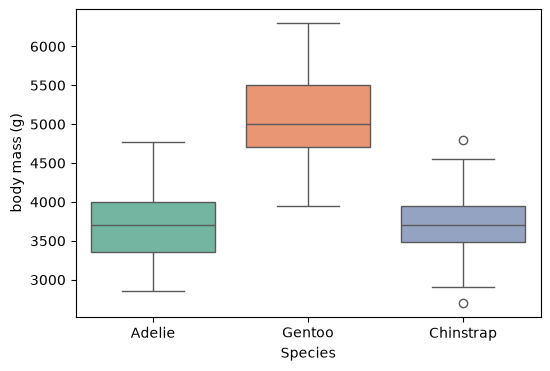

In [9]:
# Remember from our in-class example that Gentoo penguins are significantly larger than the other two species. 

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=peng.dropna(subset=["species"]),
    x="species",
    y="body_mass_g",
    hue="species",
    palette="Set2",
    legend=False
)
plt.xlabel("Species")
plt.ylabel("body mass (g)")
plt.show()

In [10]:
# Now let's look at how species are broken down across islands. 

# A simple crosstab of island against species answers the question immediately.
island_species = pd.crosstab(peng["island"], peng["species"])
print(island_species)
print()
print("as row percentages:")
print((island_species.div(island_species.sum(axis=1), axis=0) * 100).round(1))

species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     124
Dream          56         68       0
Torgersen      52          0       0

as row percentages:
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe       26.2        0.0    73.8
Dream        45.2       54.8     0.0
Torgersen   100.0        0.0     0.0


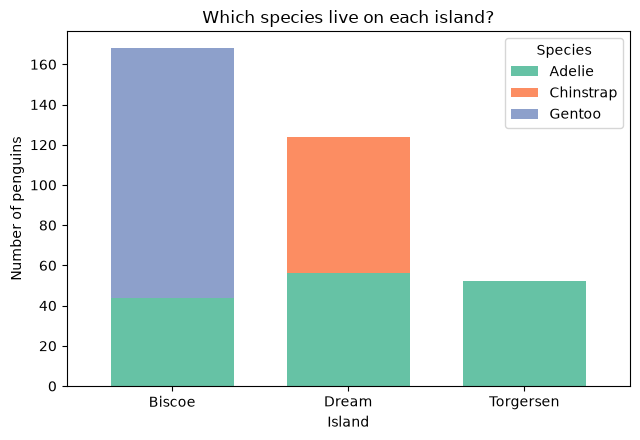

In [11]:
# The first thing that we notice from this cross-tab function is that Gentoo penguins, the largest species, 
# are only found on Biscoe island and chinstrap penguins are only found on Dream island. 
# In fact Adelie penguins are the only penguin species found on all three islands. Let's now plot this. 

fig, ax = plt.subplots(figsize=(6.5, 4.5))

island_species.plot(kind="bar", stacked=True, ax=ax,
                    color=sns.color_palette("Set2"), width=0.7)
ax.set_xlabel("Island")
ax.set_ylabel("Number of penguins")
ax.set_title("Which species live on each island?")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Species")

plt.tight_layout()
plt.show()


Q3 continued: How does this change the answer to my question in part 2? Well, the penguins on Biscoe Island are indeed larger, but this likely has nothing to do with the island itself, and more because the largest species of penguin, Gentoo penguins, are only found there. 

### Q4: Repeat the proportion test considering only one species of penguin.

In [12]:
# I am going to repeat the proportions test considering ONLY Adelie penguins, since that is the only species found on all three islands. 

# Note: For this example, I am using the same definition for "is_large" as I did previously. 
# You could redefine what large means only among the Adelie population but for simplicity in this case, we'll keep our original definition

adelie = peng_mass[(peng_mass["species"] == "Adelie")].copy()
adelie_on_biscoe = adelie["island"] == "Biscoe"


large_pengs = [
    adelie.loc[adelie_on_biscoe, "is_large"].sum(), # Large Adelie penguins on Biscoe
    adelie.loc[~adelie_on_biscoe, "is_large"].sum(), # Large Adelie penguins not on Biscoe
]
total_pengs = [
    adelie_on_biscoe.sum(), # Total Adelie Penguins on Biscoe
    (~adelie_on_biscoe).sum(), # Total Adelie Penguins not on Biscoe
]

print("Proportions: Large penguins on Biscoe: ", large_pengs[0]/total_pengs[0])
print("Proportions: Large penguins not on Biscoe: ", large_pengs[1]/total_pengs[1])

z_stat, p_value = proportions_ztest(large_pengs, total_pengs)
print(z_stat, p_value)

Proportions: Large penguins on Biscoe:  0.20454545454545456
Proportions: Large penguins not on Biscoe:  0.22429906542056074
-0.266904085463221 0.7895430109791678


Q4 continued: We can see from the proportions test above that when we consider only one species of penguin (Adelie), there is NOT a significant difference in the size of the penguins on Biscoe island vs the other islands. 

Overall, we can still state that yes, penguins on Biscoe island are larger, but the island itself is not the reason. Gentoo penguins, the largest species in this dataset, are only found in Biscoe island. This is likely where the difference is coming from, not the island itself. 

The goal of this question was two-fold:

1. Get you to practice doing a proportions test
2. Start the practice of being highly suspicious of extraordinary results. If it seems too good to be true, it often is! 

## Activity 2: Digging Futher into ANOVA with Class Data

### Q1: Looking at the data for "average number of hours of sleep" vs time since undergrad, rebin the data into three groups instead of 5. 

In [32]:
# Q1: I'll use the same code and assumptions that I used in class. Yours might be different based on 
# your completion of LabActivity0 and that's ok, as long as your data cleaning and assumptions are 
# well documented. 

df = pd.read_csv('../data/DS6021-Fall26-Anonymized.csv')

df_sleep = df[[
    "How many years ago did you receive your undergraduate degree?",
    "How many hours do you sleep in a typical night?"
]].rename(columns={
    "How many years ago did you receive your undergraduate degree?": "years_since_undergrad",
    "How many hours do you sleep in a typical night?": "sleep_hrs"
})

year_order = ["< 1 year", "1-3 years", "4-6 years", "7-10 years", "10+ years"]
df_sleep["years_since_undergrad"] = pd.Categorical(
    df_sleep["years_since_undergrad"], categories=year_order, ordered=True
)

# Average the first two numbers in each response: '6-7' -> 6.5, 'about 7 sometimes 8' -> 7.5
bounds = df_sleep["sleep_hrs"].str.extractall(r"(\d+\.?\d*)")[0].astype(float)
df_sleep["sleep_hrs"] = bounds.groupby(level=0).agg(lambda x: x.head(2).mean())

In [33]:
# Now let's rebin the data into three groups
three_bin_map = {
    "< 1 year":   "< 1 year",
    "1-3 years":  "1-3 years",
    "4-6 years":  "4+ years",
    "7-10 years": "4+ years",
    "10+ years":  "4+ years",
}
GROUP_ORDER = ["< 1 year", "1-3 years", "4+ years"]

df_sleep["years_group"] = pd.Categorical(
    df_sleep["years_since_undergrad"].map(three_bin_map),
    categories=GROUP_ORDER,
    ordered=True,
)

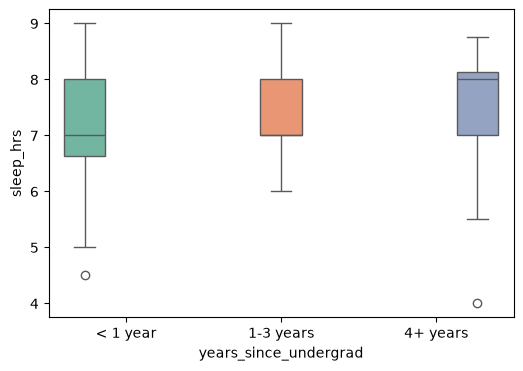

In [34]:
# And plot!

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_sleep,
    x="years_group",
    y="sleep_hrs",
    hue="years_group",
    palette="Set2"
)

plt.xlabel("years_since_undergrad")
plt.ylabel("sleep_hrs")
plt.show()

### Q2: Repeate the test for equal variance with these three groups, as well as the ANOVA. What conclusions can you draw? Are any other assumptions violated? 

In [35]:
# First, let's test equal variance. 

print(df_sleep.groupby("years_group")["sleep_hrs"].agg(["count", "mean", "std"]).round(2))

groups = [df_sleep.loc[df_sleep["years_group"] == s, "sleep_hrs"]
          for s in GROUP_ORDER]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))

             count  mean   std
years_group                   
< 1 year        50  7.07  0.98
1-3 years       17  7.41  0.85
4+ years        19  7.42  1.17
Levene's test p-value: 0.75


In [36]:
# We can see that equal variance is supported. Let's run the ANOVA.

model = ols("sleep_hrs ~ C(years_group)", data=df_sleep).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                   sum_sq    df         F    PR(>F)
C(years_group)   2.516123   2.0  1.252339  0.291179
Residual        83.379226  83.0       NaN       NaN


The ANOVA shows that there is not a meaningful difference between the three groups. 

**Are other assumptions violated?** 

Independence is also an assumption when doing ANOVA. We can assume that our data are independent, since each observation comes from a different student. We may not always know this or be able to make this assumption, but here it is fine. 

Normality is another assumption that we should check, but because we did not cover it in class, you will not lose points if you don't explicitly check it here. 

### Q3 Reflection

3a. **How are the original buckets reflective of a poor survey design?** 
* The buckets themselves are not equally partitioned and they increase in width <1 year is a <12 month spread, while 10+ years is unbounded. 
* The number of students in each of the original buckets is unbalanced. The majority of students graduated less than one year ago, while there are very few students in the 10+ years bucket. (Note: This is not something we necessarily would have known prior to administering the survey.)

3b. **Does splitting our data into three buckets vs five improve the survey design?**
* This helps a little bit, in that the number of students in each bucket is less unbalanced, though still not what we would want. It also doesn't really solve the issue of the buckets being of uneven duration (the last bucket is now 4+ years vs 10+ years, which is arguably worse). Ultimately, three buckets isn't much better than 5. 

3c. **If we were redesigning this survey, what would you recommend in order to answer the
question about whether or not students who graduated more recently get more or less
sleep than students who graduated longer ago?** 
* To more meaningfully assess whether or not time since graduation is a meaningful predictor of the number of hours of sleep one might get, we need a numeric rather than categorical variable. The best thing to do in this instance would be to ask students the number of months that had elapsed since graduation or ask them in what year they graduated. We could then more meaningfully investigate the relationship between hours of sleep and time since graduation. In using categories rather than a numeric answer, we are losing information. A student who graduated 13 months ago and 30 months ago are grouped into the same bucket, for example, and, in doing the ANOVA analysis, 


### Q4 Reflection

The class survey we sent out was intended to give us information about you, but also provide an example of real-world data. Even with a small sample size, the data were messy, and had inconsistencies and required cleaning. 

In addition, we didn't know a priori whether or not this dataset would provide us with meaningful information, or whether standard statistical analyses were even appropriate. Oftentimes, in spite of our best intentions or hopes, the data we have to work with do not provide us with meaningful statistical information. As an example, in 2025, many more students had Android phones than in 2026, making this a more useful axis along which to explore the data. This year, because so many more students had iPhones, comparisons between iPhone and Android users is less meaningful.

This exercise also provides us with insight into how surveys need to be thoughtfully designed. The example with the buckets for time since graduation is a great one: I arbitrarily chose those buckets, without knowing who might end up in which group. Qualitatively, it gave me information that most students in the MSDS program have graduated from college somewhat recently, and that is useful for me as an instructor to know, but from a statistical perspectve, it was hard to use these groupings for more meaningful analysis. 

Finally, throughout this notebook, we've focused on specific statistical tests, and each test rests on an underlying set of assumptions, most of which are not followed in real data sets and that impacts the validity of the statistical test. This is something that you must always bear in mind when you are using found data (e.g. data that was collected for some other purpose). 

## Activity 3: Migraine Drug Formulations

### Q1: Visualize Pain Ratings + Interpret the Results

In [19]:
# Load the dataset and check for missing data

trial = pd.read_csv("../data/Clinical_trial.csv")

print("shape:", trial.shape)
print("missing values:", trial.isna().sum())
print()

shape: (27, 2)
missing values: Drug           0
Pain_Rating    0
dtype: int64



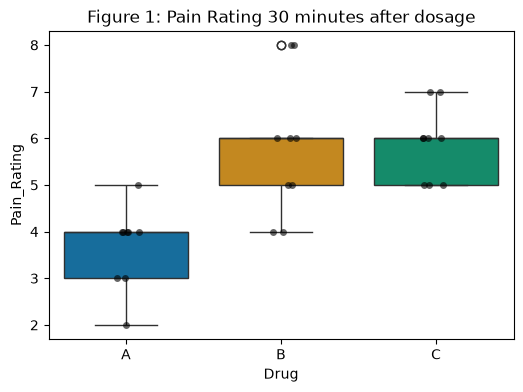

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=trial,
    x="Drug",
    y="Pain_Rating",
    hue="Drug",
    palette= sns.color_palette("colorblind", 3),
)

sns.stripplot(data=trial, x="Drug", y="Pain_Rating", color="black", jitter=True, alpha=0.6)

plt.title("Figure 1: Pain Rating 30 minutes after dosage")
plt.xlabel("Drug")
plt.ylabel("Pain_Rating")
plt.show()

Q1 continued: This graph seems to reveal that Drug A seems to result in lower pain ratings vs B and C 30 minutes after taking the drug. 

### Q2 Evaluation of Drug Formulations. 

As a data scientist, I want to explore which of the three drug formulations results in reduced pain from migraine headaches. To do this in a statistically relevant way, I will assume the null hypothesis, and then do an ANOVA to assess if I can reject the null hypothesis and conclusively state whether or not Drug A, B, or C is better at reducing migraine headache pain. Following this analysis, I'll communicate the results to key stakeholders. The plot generated above suggests (but does not prove) that A is the best medication, so we need to dig in further. 

In [21]:
# First, we'll check our assumptions. 

# Independence is satisfied, since each of the data points is taken from an individual human. 

# Let's also assess equal variance.

groups_trial = [trial.loc[trial["Drug"] == g, "Pain_Rating"].astype(float) # Note we are treating the pain threshold has numeric, though it could also be categorical. 
                for g in ["A", "B", "C"]]

lev_stat, lev_p = stats.levene(*groups_trial) 
print(lev_stat, lev_p)

1.666666666666667 0.210002143961066


In [ ]:
# Based on the Levene test, we can see that the equal variance assumption holds. 
# As with the above question, we should check for normality, but since we did not cover this explicitly in class
# you will not lose points if you did not include it. 
# Now that we have satisfied the necessary conditions for an ANOVA, lets do it. 

model = ols("Pain_Rating ~ C(Drug)", data=trial).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

             sum_sq    df         F    PR(>F)
C(Drug)   28.222222   2.0  11.90625  0.000256
Residual  28.444444  24.0       NaN       NaN


In [24]:
# This tells us that at least one of the drug formulations is significantly different from the others. 
# Now let's do the TukeyHSD comparison to see which ones 

tukey = pairwise_tukeyhsd(trial["Pain_Rating"], trial["Drug"], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   2.1111 0.0011  0.8295 3.3927   True
     A      C   2.2222 0.0006  0.9406 3.5038   True
     B      C   0.1111 0.9745 -1.1705 1.3927  False
---------------------------------------------------


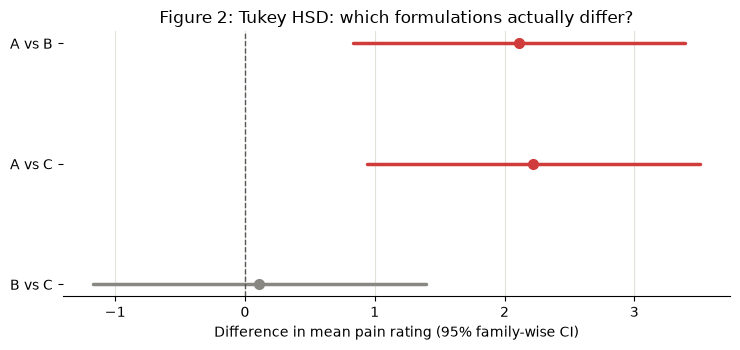

In [25]:
# This tells us that A is significantly different from B and C, but we cannot conclude that B and C different from each other. 
# We can now visualize this:

tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                        columns=tukey._results_table.data[0])
tukey_df["comparison"] = tukey_df["group1"] + " vs " + tukey_df["group2"]

fig, ax = plt.subplots(figsize=(7.5, 3.6))
sig_color, nonsig_color = "#d03b3b", "#898781"

for i, row in tukey_df.iloc[::-1].reset_index(drop=True).iterrows():
    color = sig_color if row["reject"] else nonsig_color
    ax.plot([row["lower"], row["upper"]], [i, i], color=color,
            linewidth=2.5, solid_capstyle="round")
    ax.plot(row["meandiff"], i, "o", color=color, markersize=7)

ax.axvline(0, color="#555555", linewidth=1, linestyle="--")
ax.set_yticks(range(len(tukey_df)))
ax.set_yticklabels(tukey_df["comparison"][::-1])
ax.set_xlabel("Difference in mean pain rating (95% family-wise CI)")
ax.set_title("Figure 2: Tukey HSD: which formulations actually differ?")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
plt.tight_layout()
plt.show()

**Q2 Update to non-technical stakeholders**

*Note to DS6021 students: I am writing this answer as though it is in a report, briefing, or possibly an email, to be read by a non-technical stakeholder. It could also be presented in a slide deck. This is an example of how I might present it, but there are multiple good ways to do this.*

What we did: As you are aware, we gave 27 different volunteers one of three different migraine medications marked A, B, or C. We then asked them to rate their pain 30 minutes after taking the drug. Based on this feedback, we looked at whether any of the drugs were more efficacious in reducing the pain experienced by these migraine sufferers. 

Based on the data provided and shown in Figure 1, we can see that Drug A seems to have the most impact on migraine pain, since the average overall rating is lower than Drugs B and C, which appear to not differ much. While this visual is helpful, it does not definitively prove anything so we did some additional testing. 

We did an Analysis of Variance test, which is common in these scenarios, to test for a statistically meaningful difference between the three groups. This test resulted in a p-value of 0.00026, indicating that the differences among the groups are in fact significant. We then followed up with another test to identify where the differences lie. The differences between A/B and A/C are significant, but there is no meaningful difference between B and C. Additional details of these analyses can be provided if you are interested. 

Based on this analysis, Drug A seems to be the best formulated from the standpoint of reducing migraine pain. 

Although the results of this test are statistically sound, there are a number of variables not considered by this data, including: 
* Different individuals will rate pain differently--a 9 for one person could be a 6 for another, which is not reflected in the data. 
* We are looking at only one metric--pain after 30 minutes. We don't know how long relief lasts beyond that. 
* We have not collected any other information such a sex, patient history, migraine frequency, etc. Those could also impact efficacy. 


### Q3: Supervised Learning and Prediction vs Inference

1. If we wanted to build a supervised learning model, one prediction goal could be: for a given patient profile, which drug would result in the lowest predicted pain rating. This would require having profiles for each patient, similar to what I noted in the answer to the question above: sex, patient history, migraine frequency, etc. We could choose the right subset of these features to build a predictive model, and our target variable would be: Which drug formulation gives this lowest pain score? 

2. Inference is useful for answering questions about how different drugs will impact the overall population. Examples include: 
* Which drug causes lower pain on average? 
* If we change the dosage of a given drug by a few milligrams, what is the pain response? 
* If one drug has an overwhelmingly different pain response, should we discontinue production of the other drugs? 

3. Prediction is useful for individualized forecasting, as described above. What should we do for each specific patient? 

## Activity 4: Statistical Power

This activity will make use of the statistical power code that we used in class. 

### Q1: Assuming an alpha of 0.05 and a power of 0.8, what is the minimum effect size we could measure after 4 days? 

In [26]:
# Let's start with the information that was given to us. 
# I'll write it in the same format that we used in class

MEAN_AOV = 12       # Mean number of minutes on the app for the current version (Note: AOV is a misnomer here, but I'm keeping for consistency with our in class notebook)
SD_AOV = 4          # Stated standard deviation in minutes
DAILY_PER_ARM = 300 # Number of users routed to each version of the app per day
ALPHA = 0.05        # Stated alpha we are assuming
OBSERVED_B = 12.5   # Observed difference after 4 days

# What is the percent difference we have observed after 4 days
print(f"After 4 days, we observed a {((OBSERVED_B-MEAN_AOV)/MEAN_AOV)*100:.4f}% difference")


After 4 days, we observed a 4.1667% difference


In [27]:
# Now let's use the function in our statistical power notebook to calculate the mde after 4 days. 
analysis = TTestIndPower()

def mde_for_n(n_per_arm, power=0.80, alpha=ALPHA):
    """Smallest Cohen's d detectable at the given power, converted to a % lift in AOV."""
    d = analysis.solve_power(effect_size=None, nobs1=n_per_arm, alpha=alpha,
                             power=power, ratio=1.0, alternative="two-sided")
    return d * SD_AOV / MEAN_AOV

In [28]:
n_per_arm = 4*DAILY_PER_ARM
mde = mde_for_n(n_per_arm)
mde_minutes = mde*MEAN_AOV
print(f"The minimum detectible effect after 4 days is: {(mde)*100:.4f}%")
print(f"In minutes, this is: {mde_minutes:.4f}")

The minimum detectible effect after 4 days is: 3.8140%
In minutes, this is: 0.4577


In [29]:
# Let's assume equal variance for both versions A and B. 
# We don't necessarily know that this is true, but for an estimate of this type, it is an ok starting point. 
# Based on this, we can calculate confidence intervals around our estimates

# Compare the observed effect to the MDE, and compute what the test statistic
# would be if the numbers we were given are the final ones.
OBSERVED_DIFF = (OBSERVED_B-MEAN_AOV)
observed_d = OBSERVED_DIFF / SD_AOV
se = SD_AOV * np.sqrt(2 / (4*DAILY_PER_ARM))      # standard error of the difference in means
ci_low, ci_high = OBSERVED_DIFF - 1.96 * se, OBSERVED_DIFF + 1.96 * se

print(f"MDE after 4 days:          {mde_minutes:.3f} minutes")
print(f"Observed difference:         {OBSERVED_DIFF:.3f} minutes")
print(f"-> the observed effect is only {OBSERVED_DIFF / mde_minutes:.2f}x the MDE")
print()
print(f"Observed Cohen's d:          {observed_d:.4f}")
print(f"Standard error:              {se:.4f} minutes")
print(f"95% CI for the difference:   {ci_low:.3f} to {ci_high:.3f} minutes")
print(f"    (CI width:               {ci_high - ci_low:.3f} minutes)")
print()

MDE after 4 days:          0.458 minutes
Observed difference:         0.500 minutes
-> the observed effect is only 1.09x the MDE

Observed Cohen's d:          0.1250
Standard error:              0.1633 minutes
95% CI for the difference:   0.180 to 0.820 minutes
    (CI width:               0.640 minutes)



### Q2: Should we discontinue the test and ship version B? 

The difference that we observed after 4 days between A and B was around 4.17%. At an alpha of 0.05 and a statistical power of 0.8, we calculated that the minimum detectible effect after 4 days is around 3.81%, so we have met the minimum necessary threshold to discontinue the test. However, the minimum detectible effect is only around 1.09x what we actually observed. In addition, the width of the 95% confidence interval is larger than the effect itself. It is a good idea to run this test for longer, which would help us to tighten these confidence intervals and be more confident in the observed effect. 

In [30]:
# Let's look at what more days would get us
# Let's look at both the mde confidence intervals
observed_diff = (OBSERVED_B-MEAN_AOV)/MEAN_AOV # From above

rows = []
for days in [4, 5, 7, 10, 14, 21, 28]:
    n = days * DAILY_PER_ARM
    mde = mde_for_n(n)
    se_d = SD_AOV * np.sqrt(2 / n) # Note that the standard error goes down as n goes up!
    rows.append({"days": days, "total n per arm": n, 
                 "MDE (relative lift)": mde,
                 "observed/MDE": round(observed_diff/mde,2), 
                 "95% CI width": round(2 * 1.96 * se_d, 3)})

mde_table = pd.DataFrame(rows)
mde_table["MDE (relative lift)"] = mde_table["MDE (relative lift)"].map("{:.1%}".format)
mde_table

,days,total n per arm,MDE (relative lift),observed/MDE,95% CI width
0,4,1200,3.8%,1.09,0.640
1,5,1500,3.4%,1.22,0.573
2,7,2100,2.9%,1.45,0.484
3,10,3000,2.4%,1.73,0.405
4,14,4200,2.0%,2.04,0.342
5,21,6300,1.7%,2.50,0.279
6,28,8400,1.4%,2.89,0.242


### Q3 Bullet points for leadership + Visualization

* The 30 second effect that we have observed after 4 days IS above the threshold of what we could minimally detect, given the number of users we have incorporated into this A/B test. 
* Unfortunately, even though the effect we are detecting is likely to be real, our 95% confidence interval is larger than we would like it to be and ranges from 0.18 to 0.82 minutes. This is notable given that right now the detected difference between A and B is 0.5 minutes
* We recommend running the test for three more days, to collect a week's worth of data. This give us more confidence in our results, as indicated by the plot below. 


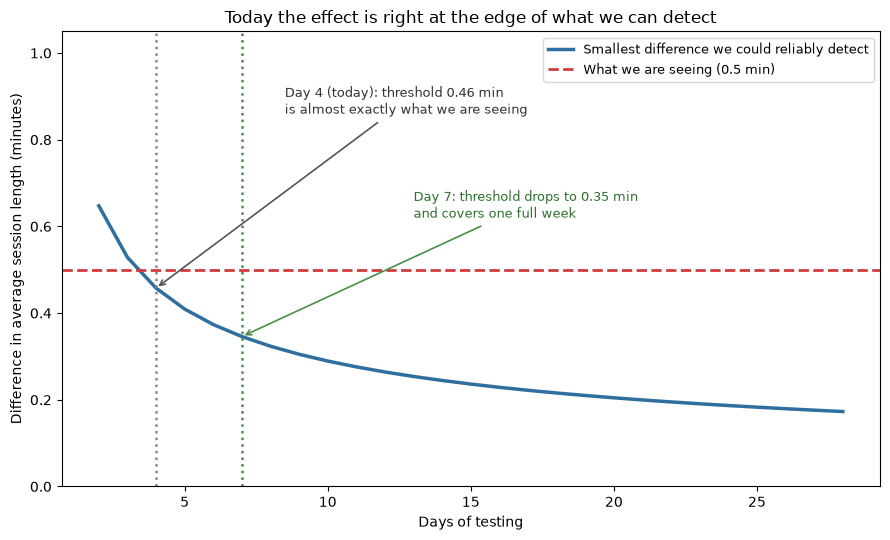

In [31]:


days_grid = np.arange(2, 29)
mde_curve = np.array([mde_for_n(int(d * DAILY_PER_ARM))*MEAN_AOV for d in days_grid])
DAYS_RUN = 4

# mde_for_n returns a RELATIVE lift, so everything on this plot is converted to
# minutes with *MEAN_AOV. observed_diff is relative too, so it needs the same
# conversion before it can share an axis with the MDE curve.
observed_minutes = observed_diff * MEAN_AOV

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(days_grid, mde_curve, linewidth=2.5, color="#2f6f9f",
        label="Smallest difference we could reliably detect")
ax.axhline(observed_minutes, color="#d03b3b", linestyle="--", linewidth=2,
           label=f"What we are seeing ({observed_minutes:.1f} min)")
ax.axvline(DAYS_RUN, color="#898781", linestyle=":", linewidth=1.8)
ax.axvline(7, color="#4a8f4a", linestyle=":", linewidth=1.8)

ax.annotate(
    f"Day {DAYS_RUN} (today): threshold {mde_minutes:.2f} min\n"
    f"is almost exactly what we are seeing",
    xy=(DAYS_RUN, mde_minutes), xytext=(8.5, 0.86),
    arrowprops=dict(arrowstyle="->", color="#555555", linewidth=1.2),
    fontsize=9.5, color="#333333",
)
ax.annotate(
    "Day 7: threshold drops to 0.35 min\nand covers one full week",
    xy=(7, mde_for_n(7 * DAILY_PER_ARM)*MEAN_AOV), xytext=(13.0, 0.62),
    arrowprops=dict(arrowstyle="->", color="#4a8f4a", linewidth=1.2),
    fontsize=9.5, color="#2f6f2f",
)
ax.set_xlabel("Days of testing")
ax.set_ylabel("Difference in average session length (minutes)")
ax.set_title("Today the effect is right at the edge of what we can detect")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### Q4: We are stopping anyway

If my collaborator said we were stopping the experiment anyway, despite my recommendations, I'd be sure to frame to leadership that although our raw numbers indicate a significant effect, we should proceed with caution. It is possible that the actual effect is smaller than what we are seeing, and if flipping to version B gives disappointing results, we should not be surprised.  

## Generative AI usage

Because I am asking you to state how you used Generative AI in doing your homework, I will be stating how I used Generative AI to provide these solutions. 

I gave Claude Code a pdf file of this lab activity, and asked for a ```.ipynb``` file in response. Essentially, I asked Claude to do this homework assignment. I then cross-referenced what Claude wrote with what I wanted to say, but I did not have Claude write this notebook that I am sharing with you. All explanatory test for the reflection questions was written by me. In many cases, Claude provided way too much superfluous detail and in more than one case, did not make the point I wanted to make. 

For all code generated by Claude, I made sure I executed and validated the answers independently, and looked up any syntax (e.g. for sklearn or statsmodels) to ensure Claude wasn't generating garbage. I did cut and paste some Claude generated code into this notebook, but not without validation. I also asked follow up questions where appropriate. (I have Claude Code embedded in VSCode.)